# Library Rentals Demand Prediction — Jeddah
## Full Data Science Project: From Raw Data to Machine Learning

**Estimated Time:** 2–3 hours

---

### Scenario

You are a data analyst at a chain of public libraries in Jeddah, Saudi Arabia. Management wants to predict how many book rentals each branch will get per hour so they can optimize staffing and inventory. They handed you a messy export from their system (`Hail_library_rentals.csv`) containing hourly rental counts alongside weather data, branch information, and membership details.

### Your Job

1. Clean and explore the data
2. Engineer useful features
3. Build and compare **4 different ML models** to predict `Rentals_Count` (one of which must be a Neural Network)
4. Recommend the best model with justification

### Dataset Columns

- `Date` — Date of the record (DD/MM/YYYY)
- `Hour` — Hour of the day (0–23)
- `Rentals_Count` — **Target variable**, number of books rented that hour
- `Temperature_C` — Temperature in Celsius
- `Humidity_pct` — Humidity percentage
- `Wind_Speed_ms` — Wind speed in m/s
- `Visibility_m` — Visibility in meters
- `Solar_Radiation_MJm2` — Solar radiation (MJ/m²)
- `Rainfall_mm` — Rainfall in mm
- `Snowfall_cm` — Snowfall in cm
- `Season` — Season of the year
- `Holiday` — Whether it's a holiday (Yes/No)
- `Functioning_Day` — Whether the library was open (Yes/No)
- `Library_Branch` — Name of the library branch
- `Top_Category` — Most rented book category that hour
- `Membership_Type` — Dominant membership type
- `Day_of_Week` — Day name


---

# Part 1: Setup and Data Loading

**Tasks**

1. Import all required libraries
2. Load the dataset
3. Display the first and last 5 rows


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('hail_library_rentals.csv')

In [3]:
display(df.head())

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
0,01/01/2023,9,51,21.7,40.6,5.0,1473.0,2.51,0.0,0,Winter,Yes,Yes,University Branch,History,Walk-in,Sunday
1,01/01/2023,10,44,25.3,70.2,7.0,1493.0,2.47,1.1,0,Winter,Yes,Yes,AL HAMRA BRANCH,Non-Fiction,Student,Sunday
2,01/01/2023,14,62,28.7,45.9,6.3,867.0,2.88,0.0,0,Winter,Yes,Yes,University Branch,Technology,Regular,Sunday
3,01/01/2023,16,91,26.9,NaN,5.2,1750.0,1.48,0.0,0,Winter,Yes,Yes,University Branch,Business,Premium,Sunday
4,01/01/2023,18,34,26.4,68.5,5.3,1531.0,0.53,0.0,0,Winter,Yes,Yes,Corniche Kiosk,Fiction,Premium,Sunday


In [4]:
display(df.tail())

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
6604,30/12/2024,14,28,25.3,65.6,2.3,1828.0,0.41,0.0,0,Winter,No,Yes,Al Hamra Branch,Science,Walk-in,Monday
6605,30/12/2024,17,73,22.3,62.9,6.6,1549.0,2.62,0.0,0,Winter,No,yes,Downtown Central,arabic literature,Walk-in,Monday
6606,30/12/2024,18,73,22.9,56.5,5.6,1769.0,0.75,0.0,0,Winter,No,Yes,University Branch,Children,Walk-in,Monday
6607,30/12/2024,19,70,22.1,60.2,5.6,1887.0,0.00,0.0,0,Winter,No,Yes,Downtown Central,Technology,Walk-in,Monday
6608,30/12/2024,20,28,18.5,66.9,3.4,1414.0,0.00,0.0,0,Winter,No,Yes,Al Hamra Branch,History,Regular,Monday


---

# Part 2: Data Inspection

**Tasks**

1. Check the shape of the dataset
2. Use `.info()` to see data types and non-null counts
3. Use `.describe()` to get statistical summary
4. Check for missing values per column
5. Check for duplicate rows


In [5]:
print(df.shape)

(6609, 17)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  6585 non-null   str    
 1   Hour                  6609 non-null   int64  
 2   Rentals_Count         6609 non-null   int64  
 3   Temperature_C         6507 non-null   float64
 4   Humidity_pct          6532 non-null   float64
 5   Wind_Speed_ms         6536 non-null   float64
 6   Visibility_m          6552 non-null   float64
 7   Solar_Radiation_MJm2  6529 non-null   float64
 8   Rainfall_mm           6555 non-null   float64
 9   Snowfall_cm           6609 non-null   int64  
 10  Season                6467 non-null   str    
 11  Holiday               6596 non-null   str    
 12  Functioning_Day       6586 non-null   str    
 13  Library_Branch        6609 non-null   str    
 14  Top_Category          6609 non-null   str    
 15  Membership_Type       6499 non-n

In [7]:
display(df.describe())

,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm
count,6609.000000,6609.00000,6507.000000,6532.000000,6536.000000,6552.000000,6529.000000,6555.00000,6609.0
mean,15.029354,45.24966,31.739219,60.029501,4.236291,1398.750305,1.273552,0.14415,0.0
std,4.325237,24.13352,8.814169,11.949281,2.148673,348.831041,1.161596,0.68549,0.0
min,8.000000,-112.00000,-46.900000,35.600000,0.500000,800.000000,0.000000,0.00000,0.0
25%,11.000000,29.00000,27.100000,50.500000,2.400000,1093.750000,0.000000,0.00000,0.0
50%,15.000000,44.00000,32.100000,60.200000,4.200000,1401.000000,1.080000,0.00000,0.0
75%,19.000000,61.00000,36.900000,68.700000,6.100000,1700.000000,2.310000,0.00000,0.0
max,22.000000,125.00000,49.200000,94.600000,8.000000,2000.000000,3.500000,5.00000,0.0


In [8]:
print(df.isnull().sum())

Date                     24
Hour                      0
Rentals_Count             0
Temperature_C           102
Humidity_pct             77
Wind_Speed_ms            73
Visibility_m             57
Solar_Radiation_MJm2     80
Rainfall_mm              54
Snowfall_cm               0
Season                  142
Holiday                  13
Functioning_Day          23
Library_Branch            0
Top_Category              0
Membership_Type         110
Day_of_Week               0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 28


---

# Part 3: Data Cleaning

This is where the real work begins. The dataset has several issues to fix.

## 3.1 Fix the Date Column

**Tasks**

1. Convert `Date` to datetime using `pd.to_datetime()` with `errors='coerce'` and `dayfirst=True`
2. Check how many dates became `NaT` (failed to parse)
3. Drop rows where `Date` is `NaT`


In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

In [11]:
print(df['Date'].isna().sum())

37


In [12]:
df.dropna(subset=['Date'], inplace=True)
print("Rows after dropping bad dates:", len(df))

Rows after dropping bad dates: 6572


## 3.2 Fix Numeric Columns

**Tasks**

1. Convert weather columns to numeric using `pd.to_numeric()` with `errors='coerce'`
2. Replace any **negative** values in `Temperature_C` and `Rentals_Count` with `NaN` (Jeddah doesn't have negative temperatures, and negative rentals don't make sense)
3. Fill missing numeric values with the **median** of each column


In [13]:
numeric_cols = ['Temperature_C', 'Humidity_pct', 'Wind_Speed_ms',
                'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
df.loc[df['Temperature_C'] < 0, 'Temperature_C'] = np.nan

In [15]:
df.loc[df['Rentals_Count'] < 0, 'Rentals_Count'] = np.nan

In [16]:
for col in numeric_cols + ['Rentals_Count']:
    df[col] = df[col].fillna(df[col].median())

In [17]:
print(df[numeric_cols + ['Rentals_Count']].describe())
print("\nMissing values remaining:")
print(df[numeric_cols + ['Rentals_Count']].isna().sum())

       Temperature_C  Humidity_pct  Wind_Speed_ms  Visibility_m  \
count    6572.000000   6572.000000    6572.000000   6572.000000   
mean       32.262386     60.038877       4.234875   1398.161442   
std         6.581977     11.877817       2.137222    347.462964   
min        16.600000     35.600000       0.500000    800.000000   
25%        27.400000     50.700000       2.400000   1095.000000   
50%        32.200000     60.200000       4.200000   1399.000000   
75%        36.800000     68.600000       6.100000   1697.250000   
max        49.200000     94.600000       8.000000   2000.000000   

       Solar_Radiation_MJm2  Rainfall_mm  Rentals_Count  
count           6572.000000  6572.000000    6572.000000  
mean               1.272063     0.142864      46.015064  
std                1.155546     0.682962      22.446051  
min                0.000000     0.000000       0.000000  
25%                0.000000     0.000000      30.000000  
50%                1.085000     0.000000      44

## 3.3 Standardize Text Columns

**Tasks**

1. For `Season`, `Library_Branch`, `Top_Category`, `Membership_Type`: strip whitespace and apply `.str.title()`
2. Fix inconsistent `Holiday` and `Functioning_Day` values — map all variations (`Y`, `yes`, `YES`) to `Yes` and (`N`, `no`, `NO`) to `No`
3. Fill any empty strings or remaining NaN in text columns with a sensible default
4. Print `.value_counts()` for each categorical column to verify


In [18]:
df['Library_Branch'] = df['Library_Branch'].str.strip().str.title()

In [19]:
df['Top_Category'] = df['Top_Category'].str.strip().str.title()

In [20]:
df['Season'] = df['Season'].str.strip().str.title()

In [21]:
df['Membership_Type'] = df['Membership_Type'].str.strip().str.title()

In [22]:
df['Holiday'] = df['Holiday'].replace({'Y': 'Yes', 'yes': 'Yes', 'YES': 'Yes',
                                       'N': 'No', 'no': 'No', 'NO': 'No'})

In [23]:
df['Functioning_Day'] = df['Functioning_Day'].replace({'Y': 'Yes', 'yes': 'Yes', 'YES': 'Yes',
                                               'N': 'No', 'no': 'No', 'NO': 'No'})

In [24]:
for col in ['Season', 'Holiday', 'Functioning_Day', 'Membership_Type']:
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].replace('', 'Unknown')

In [25]:
for col in ['Season', 'Holiday', 'Functioning_Day', 'Library_Branch', 'Top_Category', 'Membership_Type']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Season:
Season
Autumn     1634
Summer     1619
Winter     1599
Spring     1578
Unknown     142
Name: count, dtype: int64

Holiday:
Holiday
No         5288
Yes        1273
Unknown      11
Name: count, dtype: int64

Functioning_Day:
Functioning_Day
Yes        6372
No          177
Unknown      23
Name: count, dtype: int64

Library_Branch:
Library_Branch
Al Hamra Branch      1325
Downtown Central     1322
Al Rawdah Branch     1315
University Branch    1314
Corniche Kiosk       1296
Name: count, dtype: int64

Top_Category:
Top_Category
History              868
Business             860
Arabic Literature    859
Science              821
Fiction              807
Non-Fiction          802
Children             791
Technology           764
Name: count, dtype: int64

Membership_Type:
Membership_Type
Walk-In    1643
Premium    1620
Regular    1610
Student    1590
Unknown     109
Name: count, dtype: int64


## 3.4 Handle Remaining Issues

**Tasks**

1. Check whether `Snowfall_cm` is always 0 (Jeddah never gets snow), then drop that column
2. Remove duplicate rows
3. Filter out rows where `Functioning_Day == 'No'` (library was closed)
4. Reset the index


In [26]:
print("Unique Snowfall values:", df['Snowfall_cm'].unique())

Unique Snowfall values: [0]


In [27]:
df.drop(columns=['Snowfall_cm'], inplace=True)

In [28]:
df.drop_duplicates(inplace=True)
print("Rows after dropping duplicates:", len(df))

Rows after dropping duplicates: 6544


In [29]:
df = df[df['Functioning_Day'] == 'Yes']
print("Rows after filtering non-functioning days:", len(df))

Rows after filtering non-functioning days: 6344


In [30]:
df.reset_index(drop=True, inplace=True)

In [31]:
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)

Final shape: (6344, 16)

Missing values:
Date                    0
Hour                    0
Rentals_Count           0
Temperature_C           0
Humidity_pct            0
Wind_Speed_ms           0
Visibility_m            0
Solar_Radiation_MJm2    0
Rainfall_mm             0
Season                  0
Holiday                 0
Functioning_Day         0
Library_Branch          0
Top_Category            0
Membership_Type         0
Day_of_Week             0
dtype: int64

Data types:
Date                    datetime64[us]
Hour                             int64
Rentals_Count                  float64
Temperature_C                  float64
Humidity_pct                   float64
Wind_Speed_ms                  float64
Visibility_m                   float64
Solar_Radiation_MJm2           float64
Rainfall_mm                    float64
Season                             str
Holiday                            str
Functioning_Day                    str
Library_Branch                     str
Top_Catego

---

# Part 4: Exploratory Data Analysis (EDA)

Now that the data is clean, let's understand it visually. Each plot should have a clear title and labelled axes.


## 4.1 Distribution of the Target Variable

**Task:** Plot a histogram of `Rentals_Count`. What does the shape tell you?


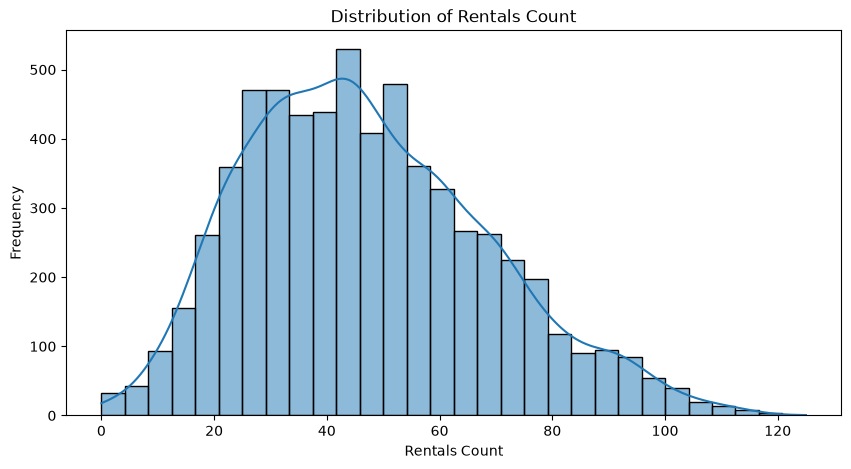

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rentals_Count'], bins=30, kde=True)
plt.title('Distribution of Rentals Count')
plt.xlabel('Rentals Count')
plt.ylabel('Frequency')
plt.show()

## 4.2 Rentals by Hour

**Task:** Plot the average `Rentals_Count` by `Hour`. When are peak hours?


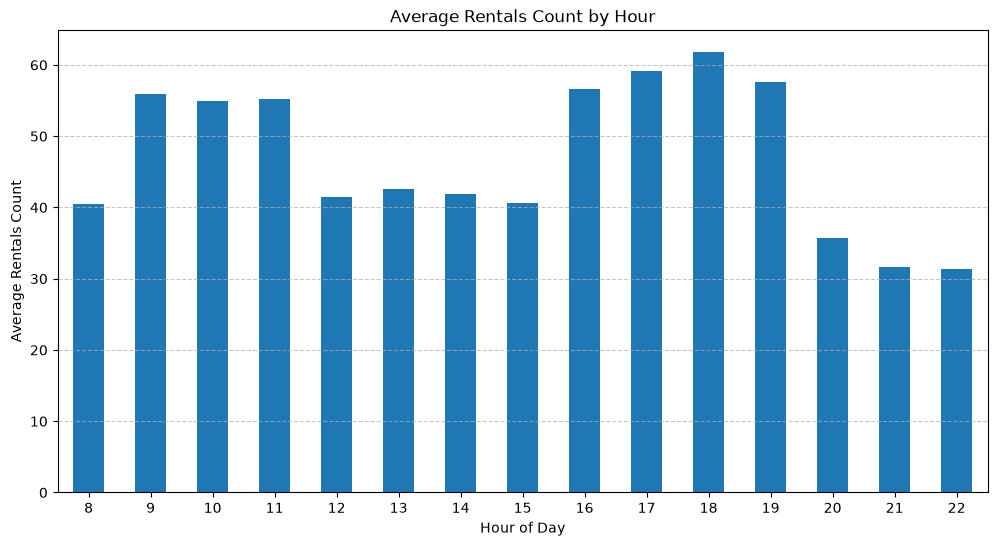

In [33]:
rentals_by_hour = df.groupby('Hour')['Rentals_Count'].mean()

plt.figure(figsize=(12, 6))
rentals_by_hour.plot(kind='bar')
plt.title('Average Rentals Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4.3 Rentals by Season

**Task:** Boxplot of `Rentals_Count` grouped by `Season`. Which season has the highest variance?


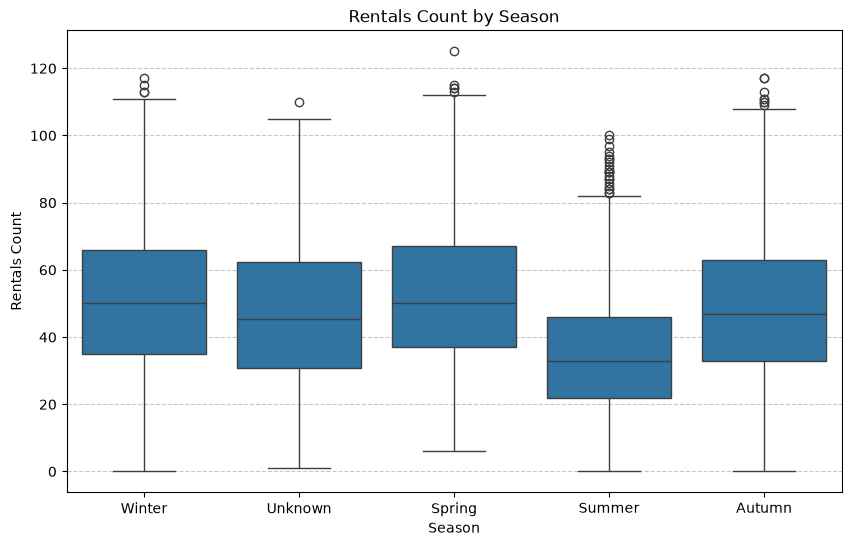

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Rentals_Count', data=df)
plt.title('Rentals Count by Season')
plt.xlabel('Season')
plt.ylabel('Rentals Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4.4 Rentals by Library Branch

**Task:** Bar plot of total rentals per `Library_Branch`. Which branch is busiest?


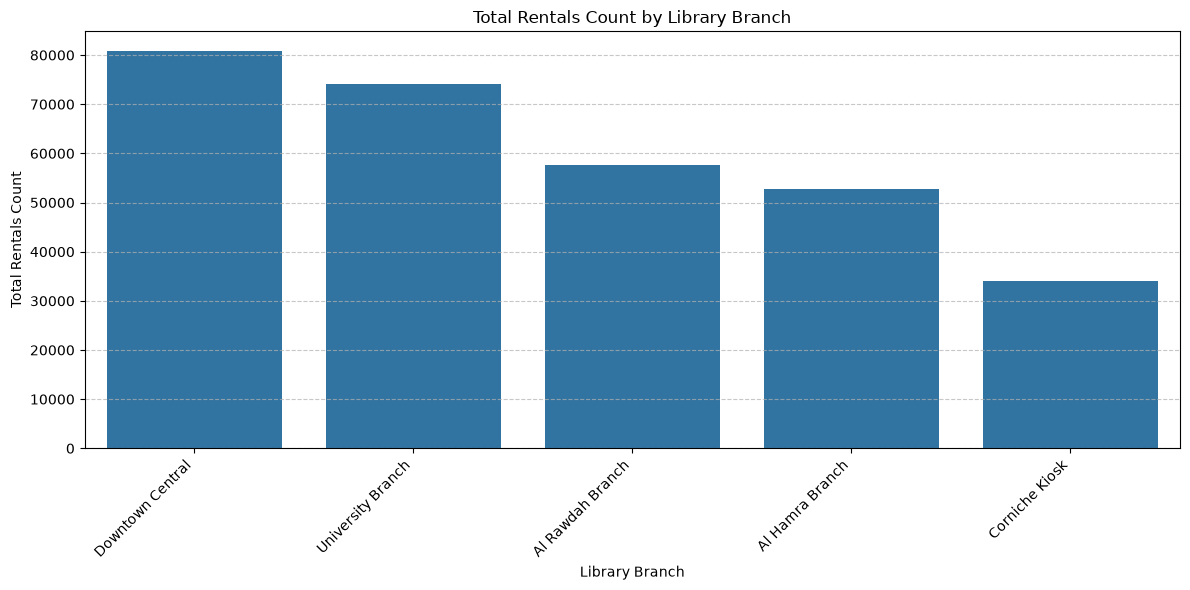

In [35]:
rentals_by_branch = df.groupby('Library_Branch')['Rentals_Count'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=rentals_by_branch.index, y=rentals_by_branch.values)
plt.title('Total Rentals Count by Library Branch')
plt.xlabel('Library Branch')
plt.ylabel('Total Rentals Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4.5 Correlation Heatmap

**Task:** Heatmap of correlations between all numeric columns. Which features correlate most with `Rentals_Count`?


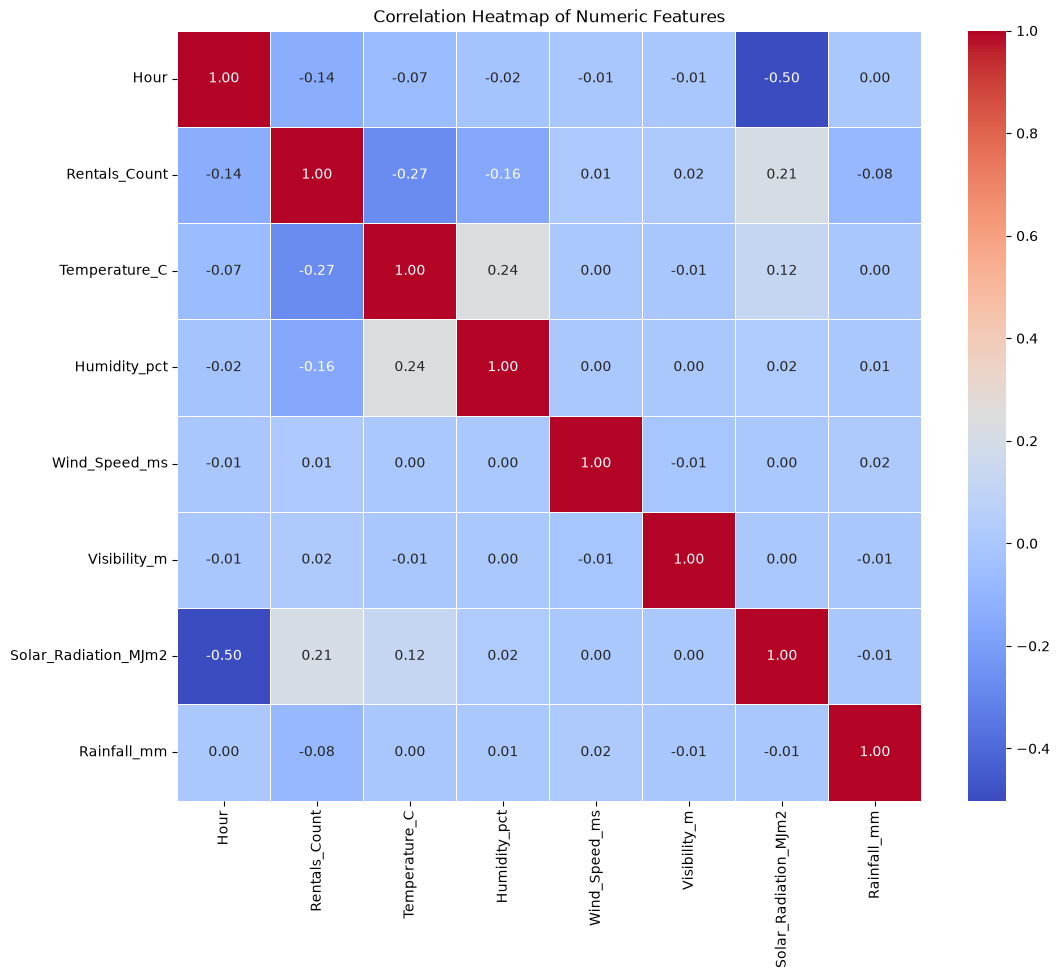

In [36]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## 4.6 Temperature vs Rentals

**Task:** Scatter plot of `Temperature_C` vs `Rentals_Count`, colored by `Season`. What relationship do you see?


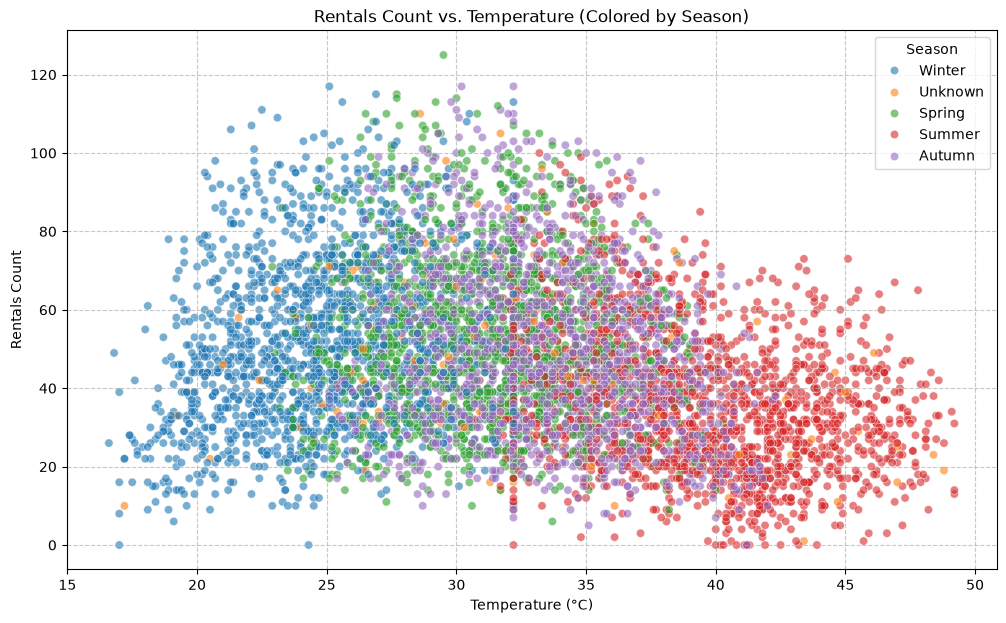

In [37]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Temperature_C', y='Rentals_Count', hue='Season', data=df, alpha=0.6)
plt.title('Rentals Count vs. Temperature (Colored by Season)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rentals Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4.7 Rentals by Day of Week

**Task:** Show average rentals per day of the week. Is there a weekend effect (Friday/Saturday in Saudi Arabia)?


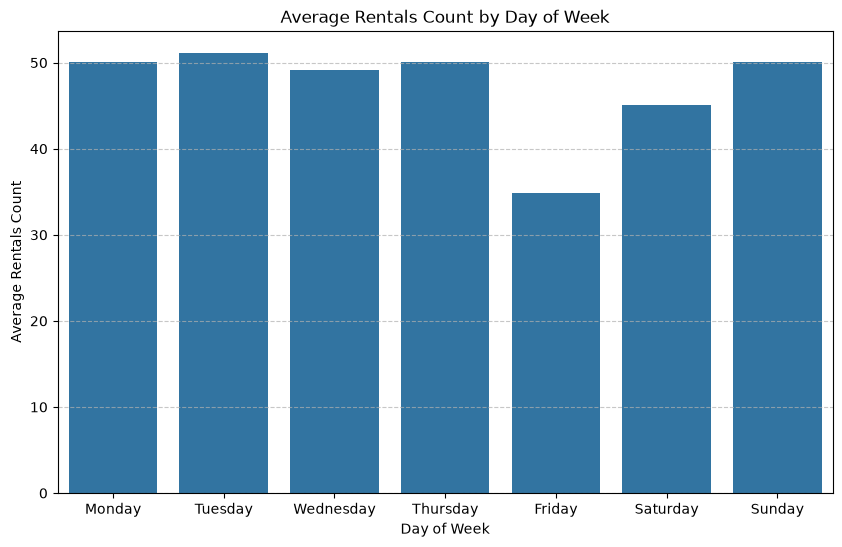

In [38]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rentals_by_day = df.groupby('Day_of_Week')['Rentals_Count'].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=rentals_by_day.index, y=rentals_by_day.values)
plt.title('Average Rentals Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Rentals Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4.8 Holiday Effect

**Task:** Compare `Rentals_Count` for holidays vs non-holidays using a boxplot or violin plot.


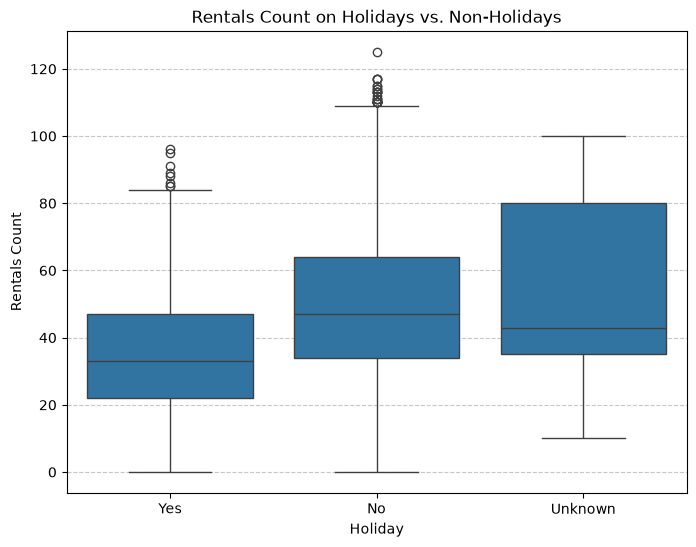

In [39]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Holiday', y='Rentals_Count', data=df)
plt.title('Rentals Count on Holidays vs. Non-Holidays')
plt.xlabel('Holiday')
plt.ylabel('Rentals Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

# Part 5: Feature Engineering

**Tasks**

1. Extract `Month` and `Day` from the `Date` column
2. Create `Is_Peak_Hour` — 1 if Hour is 9–11 or 16–19, else 0
3. Create `Temperature_Bin` — `Cool` (< 25), `Warm` (25–35), `Hot` (> 35)
4. Create `Is_Weekend` — 1 if Friday or Saturday, else 0


In [ ]:
df['Month'] = df['Date'].dt.month  # extract month from date

In [ ]:
df['Day'] = df['Date'].dt.day  # extract day of month from date

In [ ]:
df['Is_Peak_Hour'] = df['Hour'].apply(lambda x: 1 if (9 <= x <= 11) or (16 <= x <= 19) else 0)  # flag typical peak hours

In [ ]:
df['Temperature_Bin'] = pd.cut(df['Temperature_C'],
                               bins=[0, 25, 35, np.inf],
                               labels=['Cool', 'Warm', 'Hot'],
                               right=False)  # bucket temperature into cool, warm, hot categories

In [ ]:
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x in ['Friday', 'Saturday'] else 0)  # mark weekends as 1, weekdays as 0

In [ ]:
# Verify the new feature columns and sample values
print(df[['Date', 'Hour', 'Month', 'Day', 'Is_Peak_Hour', 'Temperature_Bin', 'Is_Weekend']].head(10))


        Date  Hour  Month  Day  Is_Peak_Hour Temperature_Bin  Is_Weekend
0 2023-01-01     9      1    1             1            Cool           0
1 2023-01-01    10      1    1             1            Warm           0
2 2023-01-01    14      1    1             0            Warm           0
3 2023-01-01    16      1    1             1            Warm           0
4 2023-01-01    18      1    1             1            Warm           0
5 2023-01-01    19      1    1             1            Warm           0
6 2023-01-01    20      1    1             0            Cool           0
7 2023-01-02     8      1    2             0            Cool           0
8 2023-01-02     9      1    2             1            Cool           0
9 2023-01-02    10      1    2             1            Cool           0


---

# Part 6: Encoding and Preparing for ML

**Tasks**

1. Drop the `Date` column (we already extracted Month and Day)
2. Encode categorical variables — use `pd.get_dummies()` for one-hot encoding (or `LabelEncoder` where appropriate)
3. Define feature matrix `X` and target `y`
4. Split into 80% train / 20% test
5. Apply `StandardScaler` to features


In [ ]:
df.drop(columns=['Date'], inplace=True)  # remove original Date column after extracting Month and Day

In [ ]:
categorical_cols = ['Season', 'Holiday', 'Functioning_Day', 'Library_Branch', 'Top_Category', 'Membership_Type', 'Day_of_Week', 'Temperature_Bin']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # one-hot encode categorical features

In [ ]:
X = df.drop('Rentals_Count', axis=1)  # feature matrix without target
y = df['Rentals_Count']  # target variable
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6344, 40)
Target shape: (6344,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # split data into train and test sets
print("Training set shapes:", X_train.shape, y_train.shape)
print("Test set shapes:", X_test.shape, y_test.shape)

Training set shapes: (5075, 40) (5075,)
Test set shapes: (1269, 40) (1269,)


In [ ]:
scaler = StandardScaler()  # standardize numeric features for modeling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5075, 40)
X_test_scaled shape: (1269, 40)


---

# Part 7: Model Building and Evaluation

We will build **4 different models** and compare their performance.

### Evaluation Metrics

- **R² (R-squared):** how much variance is explained by the model
- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual
- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily than MAE


## 7.1 Model 1 — Linear Regression

**Tasks**

1. Initialize and train a Linear Regression model
2. Make predictions on the test set
3. Calculate R², MAE, RMSE
4. Plot Actual vs Predicted scatter plot


In [51]:
model_lr = LinearRegression()

In [52]:
model_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](40,)","[ 0.03,-3.58,-1.27,..., 0.57, 5.44, 2.47]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.18
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,40
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(39)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](40,)","[129.98,103.92, 90.97,..., 21.6 , 16.36, 0. ]"


In [53]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [54]:
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression R²: {r2_lr:.2f}")
print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

Linear Regression R²: 0.86
Linear Regression MAE: 6.32
Linear Regression RMSE: 8.17


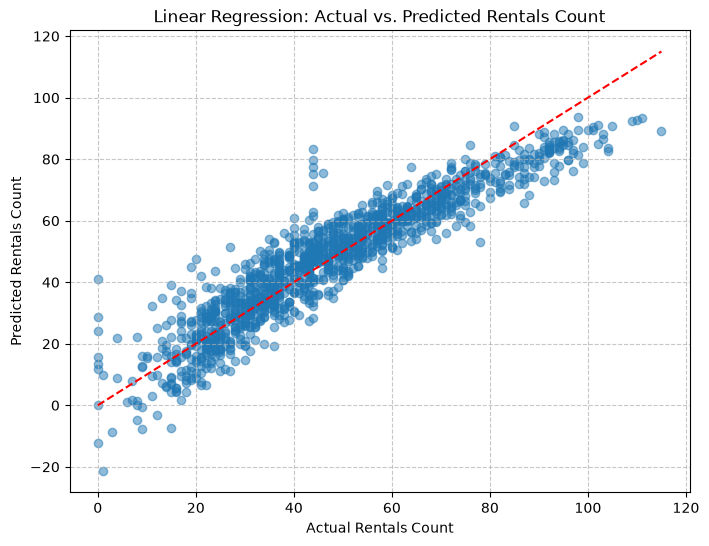

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rentals Count')
plt.ylabel('Predicted Rentals Count')
plt.title('Linear Regression: Actual vs. Predicted Rentals Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7.2 Model 2 — Decision Tree Regressor

**Tasks**

1. Initialize a Decision Tree Regressor with `max_depth=10` and `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot the top 10 most important features


In [56]:
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)

In [57]:
model_dt.fit(X_train_scaled, y_train)
y_pred_dt = model_dt.predict(X_test_scaled)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Decision Tree R²: {r2_dt:.2f}")
print(f"Decision Tree MAE: {mae_dt:.2f}")
print(f"Decision Tree RMSE: {rmse_dt:.2f}")

Decision Tree R²: 0.86
Decision Tree MAE: 5.84
Decision Tree RMSE: 8.00


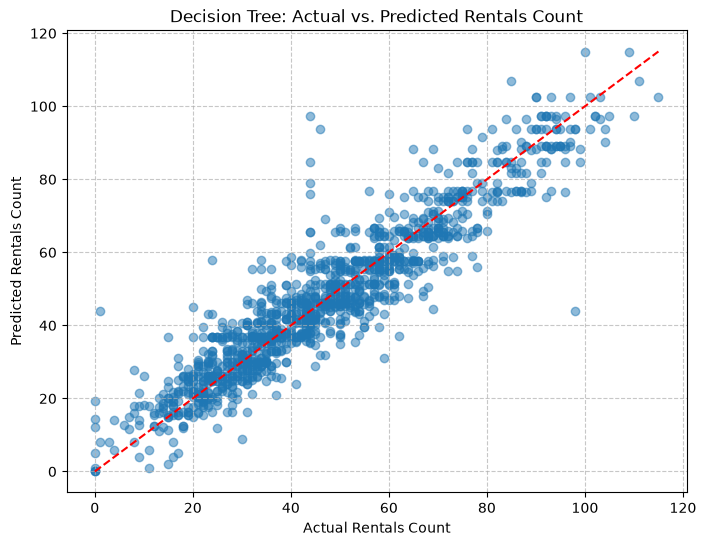

In [58]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rentals Count')
plt.ylabel('Predicted Rentals Count')
plt.title('Decision Tree: Actual vs. Predicted Rentals Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

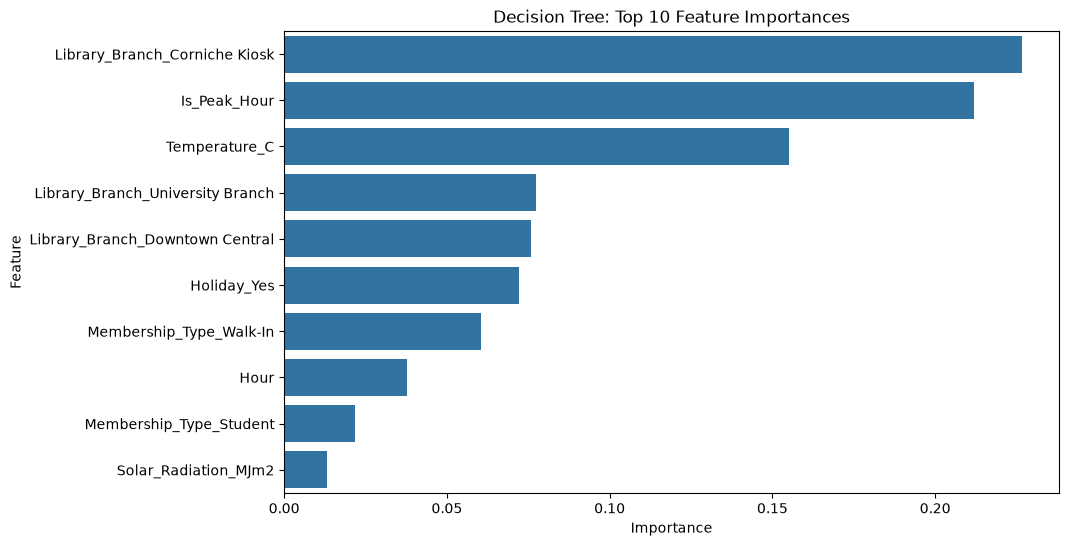

In [59]:
feature_importances_dt = pd.Series(model_dt.feature_importances_, index=X.columns)
top_10_features_dt = feature_importances_dt.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features_dt.values, y=top_10_features_dt.index)
plt.title('Decision Tree: Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 7.3 Model 3 — Random Forest Regressor

**Tasks**

1. Initialize a Random Forest with `n_estimators=100`, `max_depth=15`, `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot top 10 feature importances


In [60]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

In [61]:
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R²: {r2_rf:.2f}")
print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")

Random Forest R²: 0.92
Random Forest MAE: 4.42
Random Forest RMSE: 6.13


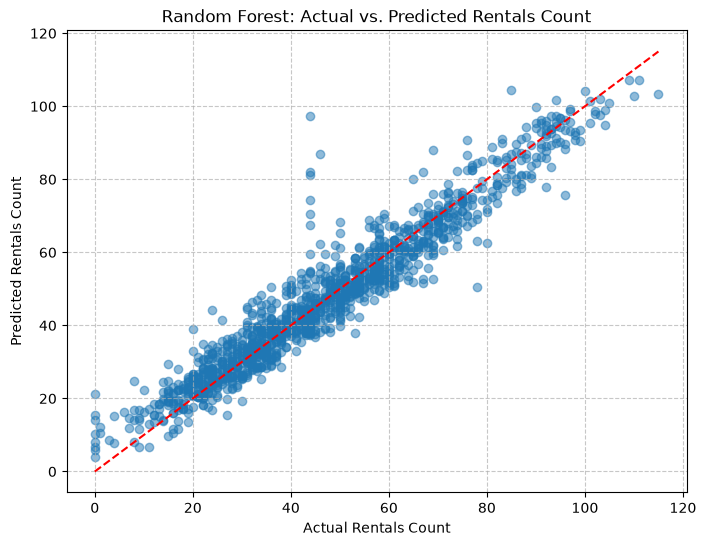

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rentals Count')
plt.ylabel('Predicted Rentals Count')
plt.title('Random Forest: Actual vs. Predicted Rentals Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

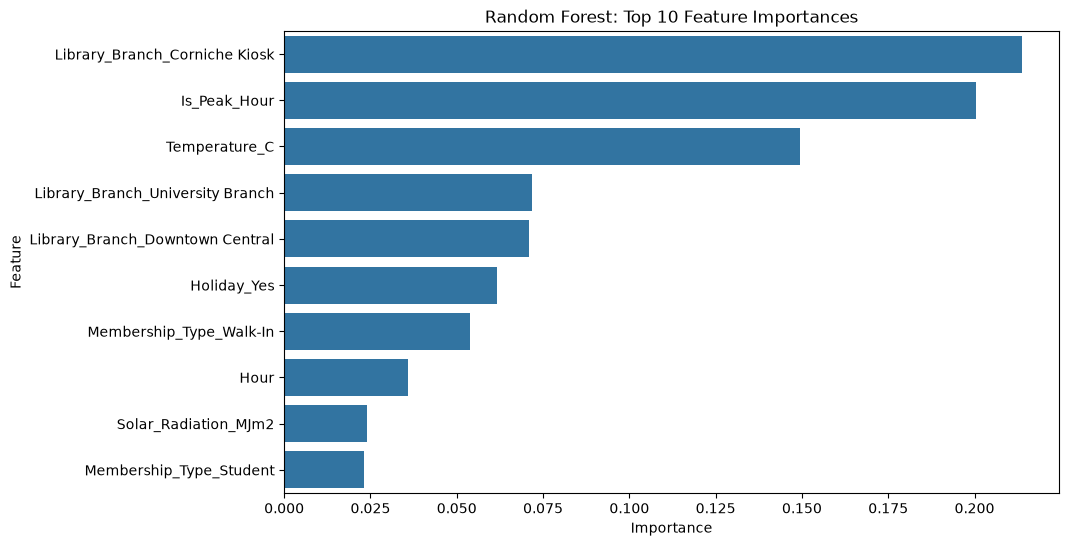

In [63]:
feature_importances_rf = pd.Series(model_rf.feature_importances_, index=X.columns)
top_10_features_rf = feature_importances_rf.nlargest(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features_rf.values, y=top_10_features_rf.index)
plt.title('Random Forest: Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 7.4 Model 4 — Neural Network

A neural network is a model loosely inspired by how the brain processes information. We will build a very simple one with just one hidden layer.

**Tasks**

1. Build a simple Sequential neural network with one hidden layer of 32 neurons (ReLU activation) and a single output neuron
2. Compile with `optimizer='adam'` and `loss='mse'`
3. Train for 50 epochs with `batch_size=32`
4. Predict on the test set and evaluate with R², MAE, RMSE


In [64]:
model_nn = MLPRegressor(hidden_layer_sizes=(32,), activation='relu', solver='adam', max_iter=1000, random_state=42)

In [65]:
# No compile step needed for scikit-learn MLPRegressor

In [66]:
history = model_nn.fit(X_train_scaled, y_train)


In [67]:
y_pred_nn = model_nn.predict(X_test_scaled)


In [68]:
r2_nn = r2_score(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))

print(f"Neural Network R²: {r2_nn:.2f}")
print(f"Neural Network MAE: {mae_nn:.2f}")
print(f"Neural Network RMSE: {rmse_nn:.2f}")

Neural Network R²: 0.93
Neural Network MAE: 4.08
Neural Network RMSE: 5.72


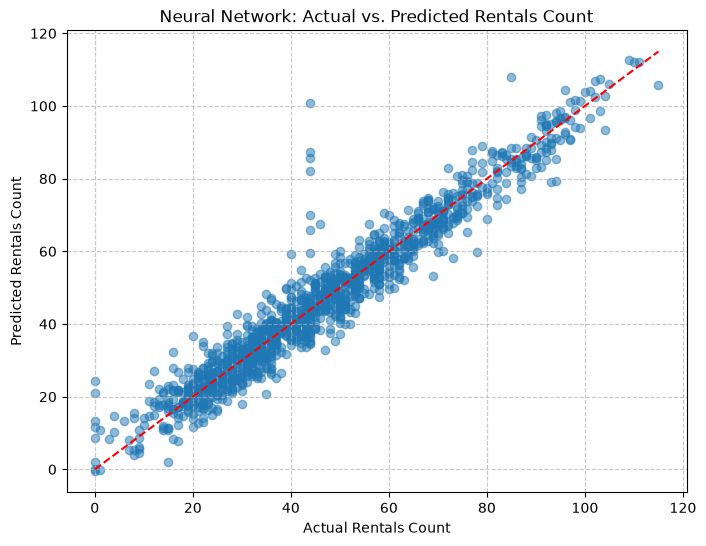

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Rentals Count')
plt.ylabel('Predicted Rentals Count')
plt.title('Neural Network: Actual vs. Predicted Rentals Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---

# Part 8: Model Comparison

**Tasks**

1. Build a summary DataFrame comparing all 4 models on R², MAE, RMSE
2. Plot a bar chart comparing R² scores
3. Write a short conclusion (3–5 sentences)


In [70]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Neural Network'],
    'R2': [r2_lr, r2_dt, r2_rf, r2_nn],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_nn],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_nn]
})

In [71]:
display(model_comparison.sort_values(by='R2', ascending=False))

,Model,R2,MAE,RMSE
3,Neural Network,0.930857,4.076348,5.724601
2,Random Forest,0.920816,4.418000,6.126193
1,Decision Tree,0.864843,5.843761,8.003693
0,Linear Regression,0.859320,6.320373,8.165610


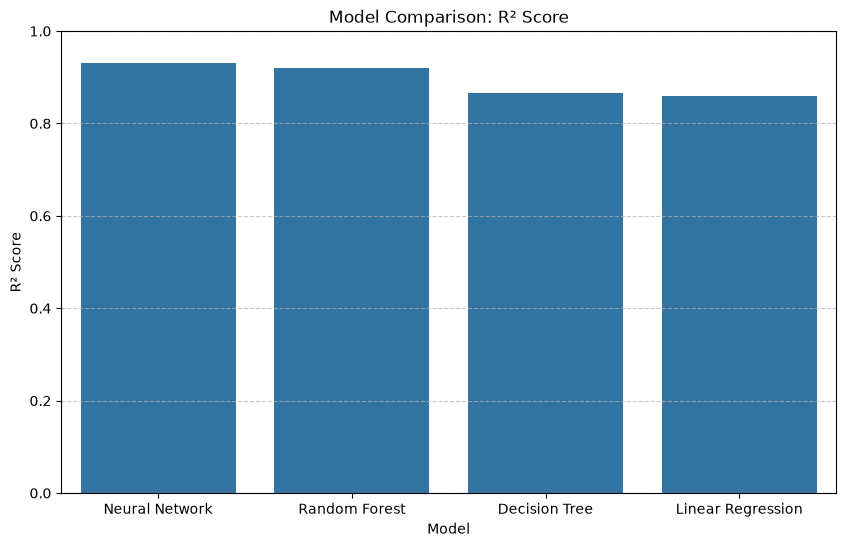

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=model_comparison.sort_values(by='R2', ascending=False))
plt.title('Model Comparison: R² Score')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion

Write 3–5 sentences answering:

1. Which model performed best on this dataset?
2. Why do you think that model outperformed the others?
3. Which features were most important for predicting rentals?
4. What would you recommend to library management based on your findings?

*Write your answer here:*


---

# Submission Checklist

- [ ] Data is fully cleaned (no missing values, no negative rentals, no duplicates)
- [ ] All categorical columns are consistently formatted
- [ ] At least 6 EDA visualizations are completed with titles and labels
- [ ] Feature engineering: `Month`, `Day`, `Is_Peak_Hour`, `Temperature_Bin`, `Is_Weekend` created
- [ ] Categorical variables are encoded
- [ ] Data is split into train/test and scaled
- [ ] **Model 1 — Linear Regression** trained and evaluated
- [ ] **Model 2 — Decision Tree** trained and evaluated with feature importance
- [ ] **Model 3 — Random Forest** trained and evaluated with feature importance
- [ ] **Model 4 — Neural Network** trained and evaluated
- [ ] All 4 models compared in a summary table and bar chart
- [ ] Conclusion written with recommendations


In [ ]:
import joblib

joblib.dump(model_nn, "model.pkl")       # replace `model` with your best trained model variable
joblib.dump(scaler, "scaler.pkl")     # replace `scaler` with your fitted StandardScaler

print("Saved model.pkl and scaler.pkl")

# TODO: Confirm both files exist (check your file explorer, or run this)
import os
print(os.path.exists("model.pkl"), os.path.exists("scaler.pkl"))

Saved model.pkl and scaler.pkl
True True


: 